# Ebola Outbreak (2014–2016): Epidemiological Data Analysis Pipeline

## 📌 Project Overview

This notebook presents an end-to-end **data cleaning, transformation, and
Exploratory Data Analysis (EDA) pipeline** for examining the Ebola outbreak
data reported between **29 August 2014 and 23 March 2016**.

The dataset contains cumulative numbers of probable, confirmed, and suspected
Ebola cases and deaths across affected countries, based on **World Health
Organization (WHO)** reporting and distributed through the Humanitarian Data
Exchange (HDX).

The primary objective is to clean, validate, restructure, and analyze these
reporting series in order to extract meaningful epidemiological insights,
including epidemic magnitude, temporal evolution, cumulative deaths, and the
final **Case Fatality Ratio (CFR %)**.

Special attention is given to data-quality issues such as distinct reporting
series (`Liberia` / `Liberia 2` and `Guinea` / `Guinea 2`), post-reshaping
missing values, and retrospective revisions in cumulative counts.

The resulting cleaned dataset provides a reproducible foundation for
comparative epidemiological analysis and future statistical or time-series
investigations.

---

## 🛠️ Key Pipeline Stages

1. **Environment Setup & Data Loading**  
   Importing the required analytical libraries and loading the original
   Ebola reporting dataset.

2. **Data Cleaning & Type Standardization**  
   Sanitizing text fields, standardizing country and indicator labels,
   and converting dates into a consistent datetime format.

3. **Data Integrity Validation**  
   Checking duplicates, reporting-series structure, and
   country-date-indicator collisions before reshaping the dataset.

4. **Structural Reshaping (Long → Wide)**  
   Pivoting the selected epidemiological indicators so that cumulative
   cases and deaths are aligned by country and reporting date.

5. **Missing-Value Diagnosis & Imputation**  
   Investigating post-pivot missing values in their temporal context and
   applying bounded linear interpolation where supported by stable
   surrounding cumulative observations.

6. **Epidemiological Analysis**  
   Examining temporal trends, final cumulative case and death counts,
   retrospective revisions, and final Case Fatality Ratios (CFR %).

7. **Comparative Visualization**  
   Using temporal plots, horizontal and grouped bar charts, and a
   Min-Max normalized heatmap to compare the epidemiological profiles
   of the affected reporting series.

---

## 🔬 Core Libraries Used

* **Pandas** — data manipulation, grouping, reshaping, and time-series preparation.
* **NumPy** — numerical operations and supporting transformations.
* **Matplotlib** — customized statistical and epidemiological visualizations.
* **Seaborn** — comparative plots and normalized heatmap visualization.

# 1. Importing Required Libraries 

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

print("Libraries successfully imported.")

Libraries successfully imported.


# 2. Loading the Dataset

In [10]:
data = pd.read_csv("data/ebola_data_db_format.csv")

print("Dimensions :", data.shape)

# View the first 5 rows of the dataset to confirm it loaded correctly
display(data.head())

Dimensions : (17585, 4)


,Indicator,Country,Date,value
0,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,3285.0
1,Cumulative number of confirmed Ebola cases,Guinea,2015-03-10,2871.0
2,Cumulative number of probable Ebola cases,Guinea,2015-03-10,392.0
3,Cumulative number of suspected Ebola cases,Guinea,2015-03-10,22.0
4,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,2170.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17585 entries, 0 to 17584
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Indicator  17585 non-null  object 
 1   Country    17585 non-null  object 
 2   Date       17585 non-null  object 
 3   value      17585 non-null  float64
dtypes: float64(1), object(3)
memory usage: 549.7+ KB


In [11]:
# Initial Data Exploration and Cleaning
print("\nValeurs manquantes :")
print(data.isnull().sum())

print("\nNombre de lignes exactement dupliquées :")
print(data.duplicated().sum())


Valeurs manquantes :
Indicator    0
Country      0
Date         0
value        0
dtype: int64

Nombre de lignes exactement dupliquées :
0


# 3. Minimal Data Cleaning

In [12]:
data["Indicator"] = data["Indicator"].str.strip()
data["Country"] = data["Country"].str.strip()

data["Date"] = pd.to_datetime(
    data["Date"],
    errors="coerce"
)

print(data.dtypes)
print("Number of countries/series:", data["Country"].nunique())

print("\nAvailable countries / series:")
print(data["Country"].unique())

Indicator            object
Country              object
Date         datetime64[ns]
value               float64
dtype: object
Number of countries/series: 12

Available countries / series:
['Guinea' 'Liberia' 'Sierra Leone' 'United Kingdom' 'Mali' 'Nigeria'
 'Senegal' 'Spain' 'United States of America' 'Italy' 'Liberia 2'
 'Guinea 2']


# 4. Verifying the Study Period

In [13]:
print("First date :", data["Date"].min())
print("Last date :", data["Date"].max())

print("\nAvailable periods by country/series :")

periode_pays = (
    data.groupby("Country")["Date"]
        .agg(["min", "max", "count"])
        .sort_values("min")
)

display(periode_pays)

First date : 2014-08-29 00:00:00
Last date : 2016-03-23 00:00:00

Available periods by country/series :


,min,max,count
Country,,,
Guinea,2014-08-29,2016-03-23,2086
Liberia,2014-08-29,2016-03-23,1540
Nigeria,2014-08-29,2016-03-23,2124
Sierra Leone,2014-08-29,2016-03-23,2303
Senegal,2014-09-05,2016-03-23,2081
United States of America,2014-10-03,2016-03-23,1932
Spain,2014-10-10,2016-03-23,1924
Mali,2014-10-25,2016-03-23,1234
United Kingdom,2015-01-02,2016-03-23,1107


# 5. Selecting the Two Core Global Indicators

In [14]:
INDICATOR_CASES = (
    "Cumulative number of confirmed, probable and suspected Ebola cases"
)

INDICATOR_DEATHS = (
    "Cumulative number of confirmed, probable and suspected Ebola deaths"
)

print("CASE Indicator :")
print(INDICATOR_CASES)

print("\nDEATHS Indicator :")
print(INDICATOR_DEATHS)
print(
    "Number of CASE observations :",
    (data["Indicator"] == INDICATOR_CASES).sum()
)

print(
    "Number of DEATH observations :",
    (data["Indicator"] == INDICATOR_DEATHS).sum()
)

CASE Indicator :
Cumulative number of confirmed, probable and suspected Ebola cases

DEATHS Indicator :
Cumulative number of confirmed, probable and suspected Ebola deaths
Number of CASE observations : 2477
Number of DEATH observations : 2485


# 6. Creating the Main Epidemiological Dataset

In [15]:
data_epi = data[
    data["Indicator"].isin(
        [INDICATOR_CASES, INDICATOR_DEATHS]
    )
].copy()

print("data_epi dimensions:", data_epi.shape)

print("\nRetained indicators :")
print(data_epi["Indicator"].unique())

display(data_epi.head(10))

data_epi dimensions: (4962, 4)

Retained indicators :
['Cumulative number of confirmed, probable and suspected Ebola cases'
 'Cumulative number of confirmed, probable and suspected Ebola deaths']


,Indicator,Country,Date,value
0,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,3285.0
4,"Cumulative number of confirmed, probable and s...",Guinea,2015-03-10,2170.0
7,"Cumulative number of confirmed, probable and s...",Liberia,2015-03-10,9343.0
11,"Cumulative number of confirmed, probable and s...",Liberia,2015-03-10,4162.0
12,"Cumulative number of confirmed, probable and s...",Sierra Leone,2015-03-10,11619.0
16,"Cumulative number of confirmed, probable and s...",Sierra Leone,2015-03-10,3629.0
23,"Cumulative number of confirmed, probable and s...",United Kingdom,2015-03-10,0.0
24,"Cumulative number of confirmed, probable and s...",United Kingdom,2015-03-10,1.0
28,"Cumulative number of confirmed, probable and s...",Mali,2015-03-10,6.0
29,"Cumulative number of confirmed, probable and s...",Mali,2015-03-10,8.0


#  7. Check for collisions BEFORE pivoting

In [16]:
collisions = data_epi.duplicated(
    subset=["Country", "Date", "Indicator"],
    keep=False
)

print(
    "Number of rows involved in collisions:",
    collisions.sum()
)
if collisions.sum() > 0:
    display(
        data_epi[collisions]
        .sort_values(["Country", "Date", "Indicator"])
        .head(30)
    )
else:
    print(
        "Aucune collision Country-Date-Indicator."
    )

Number of rows involved in collisions: 0
Aucune collision Country-Date-Indicator.


# 8. Temporal analysis of cumulative cases — main series

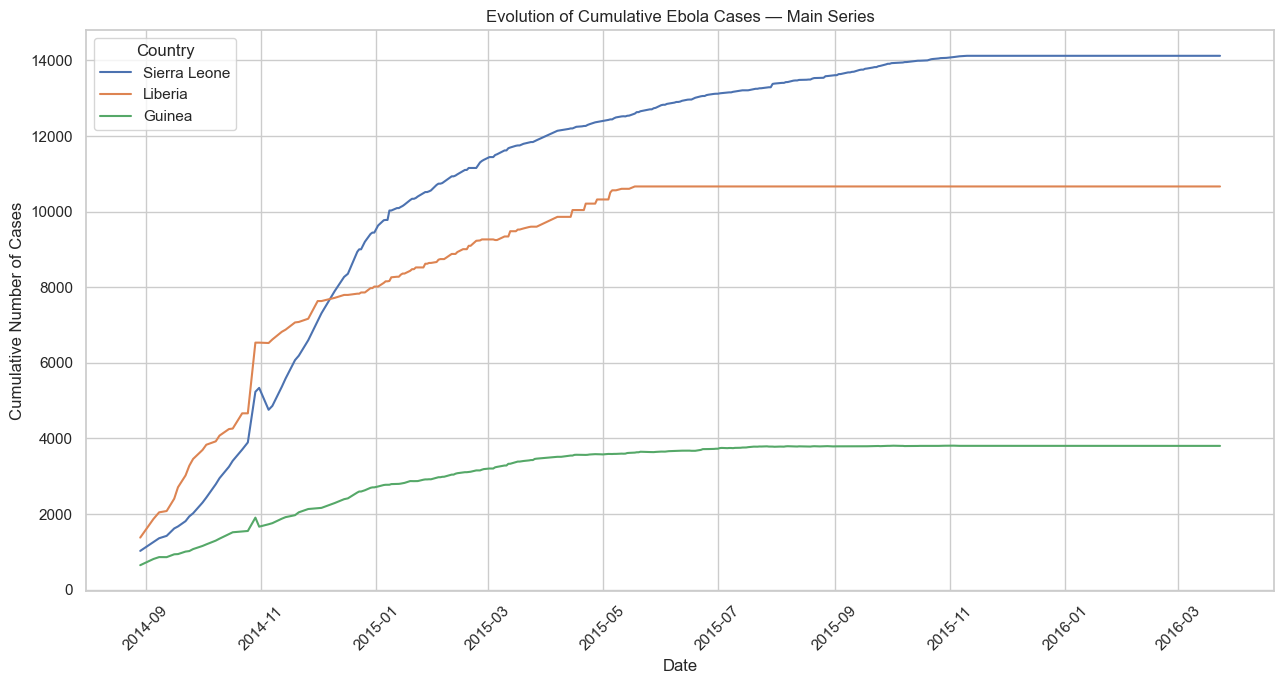

In [17]:
df_cases = data[
    data["Indicator"] == INDICATOR_CASES
].copy()

series_principales = [
    "Guinea",
    "Liberia",
    "Sierra Leone"
]

df_cases_major = (
    df_cases[
        df_cases["Country"].isin(series_principales)
    ]
    .sort_values("Date")
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=df_cases_major,
    x="Date",
    y="value",
    hue="Country"
)

plt.title(
    "Evolution of Cumulative Ebola Cases — Main Series"
)
plt.xlabel("Date")
plt.ylabel("Cumulative Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#  9. Time Series Analysis: Secondary Series (Liberia 2, Guinea 2)

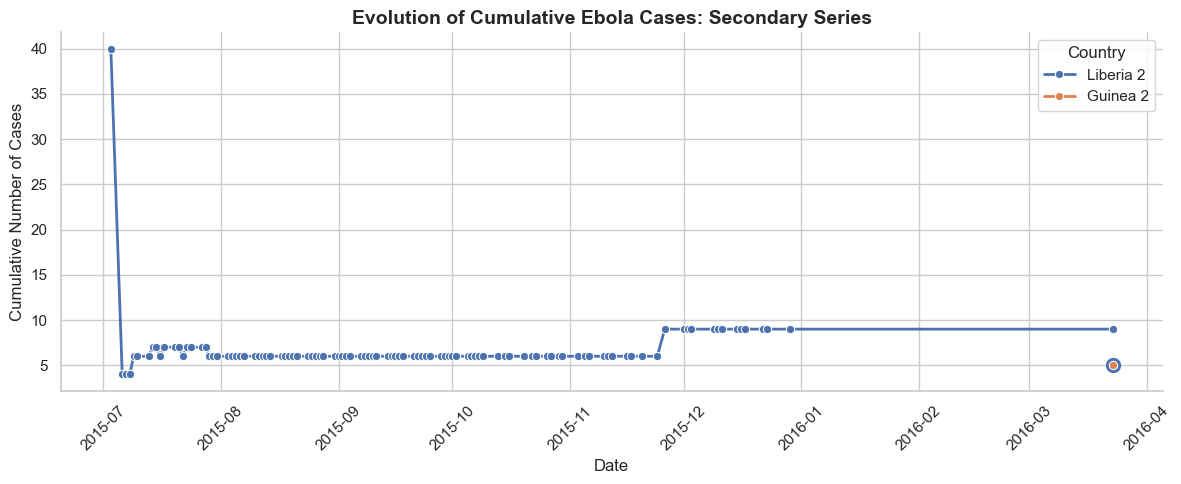

In [18]:
df_cases = data[
    data["Indicator"] == INDICATOR_CASES
].copy()
secondary_series = [
    "Liberia 2",
    "Guinea 2"
]

df_secondary = df_cases[
    df_cases["Country"].isin(secondary_series)
].sort_values("Date")

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_secondary,
    x="Date",
    y="value",
    hue="Country",
    marker="o",
    linewidth=2
)

# Important:
# Guinea 2 contains only one observation.
# We display it explicitly as a single point.
guinea2 = df_secondary[
    df_secondary["Country"] == "Guinea 2"
]

plt.scatter(
    guinea2["Date"],
    guinea2["value"],
    s=100,
    label="Guinea 2 observation"
)

plt.title(
    "Evolution of Cumulative Ebola Cases: Secondary Series",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Number of Cases")
plt.xticks(rotation=45)

sns.despine()
plt.tight_layout()
plt.show()

 # 10. Calculating the Case Fatality Ratio (CFR)

In [19]:
df_cases = data[
    data["Indicator"] == INDICATOR_CASES
]

df_deaths = data[
    data["Indicator"] == INDICATOR_DEATHS
]

# 1. Latest available observation of CASES for each series/country
final_cases = (
    df_cases
    .sort_values("Date")
    .groupby("Country")
    .tail(1)[["Country", "Date", "value"]]
    .rename(
        columns={
            "Date": "Final_Cases_Date",
            "value": "Final_Cases"
        }
    )
)

# 2. Latest available observation of DEATHS for each series/country
final_deaths = (
    df_deaths
    .sort_values("Date")
    .groupby("Country")
    .tail(1)[["Country", "Date", "value"]]
    .rename(
        columns={
            "Date": "Final_Deaths_Date",
            "value": "Final_Deaths"
        }
    )
)

# 3. Merge final cases and deaths
df_cfr_final = pd.merge(
    final_cases,
    final_deaths,
    on="Country",
    how="inner"
)

# 4. Avoid potential division by zero
df_cfr_final = df_cfr_final[
    df_cfr_final["Final_Cases"] > 0
].copy()

# 5. Calculate Case Fatality Rate (CFR)
df_cfr_final["Final_CFR_%"] = (
    df_cfr_final["Final_Deaths"]
    / df_cfr_final["Final_Cases"]
) * 100

# 6. Sort in descending order
df_cfr_final = (
    df_cfr_final
    .sort_values("Final_CFR_%", ascending=False)
    .reset_index(drop=True)
)

display(df_cfr_final)


,Country,Final_Cases_Date,Final_Cases,Final_Deaths_Date,Final_Deaths,Final_CFR_%
0,Guinea 2,2016-03-23,5.0,2016-03-23,4.0,80.000000
1,Mali,2016-03-23,8.0,2016-03-23,6.0,75.000000
2,Guinea,2016-03-23,3804.0,2016-03-23,2536.0,66.666667
3,Liberia,2016-03-23,10666.0,2016-03-23,4806.0,45.059066
4,Nigeria,2016-03-23,20.0,2016-03-23,8.0,40.000000
5,Liberia 2,2016-03-23,9.0,2016-03-23,3.0,33.333333
6,Sierra Leone,2016-03-23,14122.0,2016-03-23,3955.0,28.005948
7,United States of America,2016-03-23,4.0,2016-03-23,1.0,25.000000
8,United Kingdom,2016-03-23,1.0,2016-03-23,0.0,0.000000
9,Senegal,2016-03-23,1.0,2016-03-23,0.0,0.000000


# 11. Visualizing the CFR

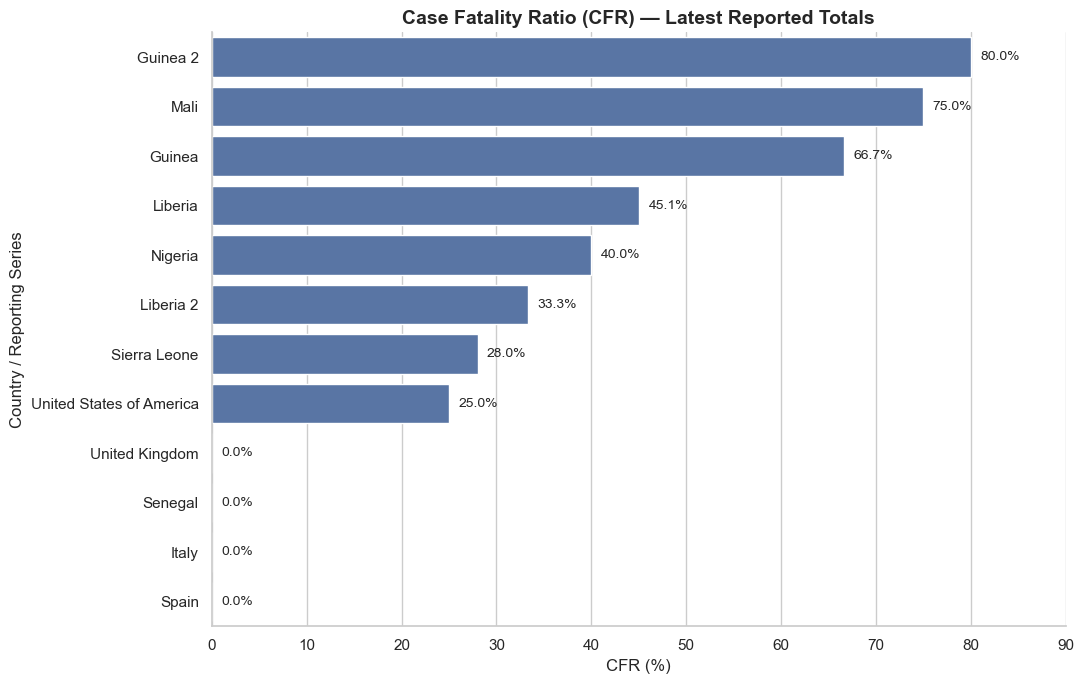

In [20]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=df_cfr_final,
    x="Final_CFR_%",
    y="Country"
)

# Add values on top of the bars
for index, value in enumerate(df_cfr_final["Final_CFR_%"]):
    plt.text(
        value + 1,
        index,
        f"{value:.1f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Case Fatality Ratio (CFR) — Latest Reported Totals",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("CFR (%)")
plt.ylabel("Country / Reporting Series")

plt.xlim(0, 90)

sns.despine()
plt.tight_layout()
plt.show()


# 12. Reshaping Data for Comparative Analysis

In [21]:
data_ml = data[
    data["Indicator"].isin(
        [INDICATOR_CASES, INDICATOR_DEATHS]
    )
].copy()

indicator_map = {
    INDICATOR_CASES: "total_cases_all",
    INDICATOR_DEATHS: "total_deaths_all"
}

data_ml["Indicator"] = (
    data_ml["Indicator"]
    .map(indicator_map)
)

print("data_ml dimensions:", data_ml.shape)

print("\nIndicator distribution:")
print(data_ml["Indicator"].value_counts())

display(data_ml.head())


data_ml dimensions: (4962, 4)

Indicator distribution:
Indicator
total_deaths_all    2485
total_cases_all     2477
Name: count, dtype: int64


,Indicator,Country,Date,value
0,total_cases_all,Guinea,2015-03-10,3285.0
4,total_deaths_all,Guinea,2015-03-10,2170.0
7,total_cases_all,Liberia,2015-03-10,9343.0
11,total_deaths_all,Liberia,2015-03-10,4162.0
12,total_cases_all,Sierra Leone,2015-03-10,11619.0


# 13. Checking for Duplicates (Post-Rename)

In [22]:
collisions_ml = data_ml.duplicated(
    subset=["Country", "Date", "Indicator"],
    keep=False
)

print(
    "Number of rows involved in collisions:",
    collisions_ml.sum()
)

if collisions_ml.sum() > 0:
    display(
        data_ml[collisions_ml]
        .sort_values(["Country", "Date", "Indicator"])
    )
else:
    print("No Country-Date-Indicator collisions detected.")


Number of rows involved in collisions: 0
No Country-Date-Indicator collisions detected.


# 14. Pivoting Data (Long to Wide Format)

In [23]:

df_pivoted = (
    data_ml
    .pivot(
        index=["Date", "Country"],
        columns="Indicator",
        values="value"
    )
    .reset_index()
)

# Remove the technical column axis name
df_pivoted.columns.name = None

# Sort chronologically
df_pivoted = (
    df_pivoted
    .sort_values(["Date", "Country"])
    .reset_index(drop=True)
)

print("Dimensions before pivot:", data_ml.shape)
print("Dimensions after pivot:", df_pivoted.shape)

display(df_pivoted.head(15))


Dimensions before pivot: (4962, 4)
Dimensions after pivot: (2485, 4)


,Date,Country,total_cases_all,total_deaths_all
0,2014-08-29,Guinea,648.0,430.0
1,2014-08-29,Liberia,1378.0,694.0
2,2014-08-29,Nigeria,19.0,7.0
3,2014-08-29,Sierra Leone,1026.0,422.0
4,2014-09-05,Guinea,812.0,517.0
5,2014-09-05,Liberia,1871.0,1089.0
6,2014-09-05,Nigeria,22.0,8.0
7,2014-09-05,Senegal,1.0,0.0
8,2014-09-05,Sierra Leone,1261.0,491.0
9,2014-09-08,Guinea,862.0,555.0


# 15. Diagnosing Missing Values After Pivot

In [24]:
# 1. Number of missing values
print("Missing values after pivot:")
print(df_pivoted.isna().sum())

# 2. Percentage of missing values
print("\nPercentage of missing values:")
print(
    (df_pivoted.isna().mean() * 100).round(2)
)

# 3. Affected rows
missing_rows = df_pivoted[
    df_pivoted.isna().any(axis=1)
].copy()

print(
    "\nNumber of rows containing at least one missing value:",
    len(missing_rows)
)

display(missing_rows)


Missing values after pivot:
Date                0
Country             0
total_cases_all     8
total_deaths_all    0
dtype: int64

Percentage of missing values:
Date                0.00
Country             0.00
total_cases_all     0.32
total_deaths_all    0.00
dtype: float64

Number of rows containing at least one missing value: 8


,Date,Country,total_cases_all,total_deaths_all
303,2015-01-08,Mali,NaN,6.0
305,2015-01-08,United Kingdom,NaN,0.0
308,2015-01-09,Mali,NaN,6.0
310,2015-01-09,United Kingdom,NaN,0.0
313,2015-01-12,Mali,NaN,6.0
315,2015-01-12,United Kingdom,NaN,0.0
318,2015-01-13,Mali,NaN,6.0
320,2015-01-13,United Kingdom,NaN,0.0


# 16. Contextual Analysis of Missing Values

In [25]:
pays_nan = ["Mali", "United Kingdom"]

contexte_nan = (
    df_pivoted[
        (df_pivoted["Country"].isin(pays_nan)) &
        (df_pivoted["Date"].between("2015-01-01", "2015-01-20"))
    ]
    .sort_values(["Country", "Date"])
)

display(contexte_nan)

,Date,Country,total_cases_all,total_deaths_all
267,2015-01-02,Mali,8.0,6.0
276,2015-01-05,Mali,8.0,6.0
285,2015-01-06,Mali,8.0,6.0
294,2015-01-07,Mali,8.0,6.0
303,2015-01-08,Mali,NaN,6.0
308,2015-01-09,Mali,NaN,6.0
313,2015-01-12,Mali,NaN,6.0
318,2015-01-13,Mali,NaN,6.0
323,2015-01-14,Mali,8.0,6.0
332,2015-01-15,Mali,8.0,6.0


## 17. Imputing Missing Values (Linear Interpolation)

Analysis of neighboring observations shows that the 8 missing values for `total_cases_all` 
are located within periods where the cumulative count remains constant. The values are
therefore imputed using interpolation within each reporting series, without altering the original data structure.


In [26]:
# Backup copy
df_clean = df_pivoted.copy()

# Sort series correctly before imputation
df_clean = (
    df_clean
    .sort_values(["Country", "Date"])
    .reset_index(drop=True)
)

# Linearly interpolate only inside each country's series
df_clean["total_cases_all"] = (
    df_clean
    .groupby("Country")["total_cases_all"]
    .transform(
        lambda x: x.interpolate(
            method="linear",
            limit_area="inside"
        )
    )
)

print("Missing values after imputation:")
print(df_clean.isna().sum())

print("\nDimensions:", df_clean.shape)


Missing values after imputation:
Date                0
Country             0
total_cases_all     0
total_deaths_all    0
dtype: int64

Dimensions: (2485, 4)


In [27]:
verification = df_clean[
    (df_clean["Country"].isin(["Mali", "United Kingdom"])) &
    (df_clean["Date"].between("2015-01-07", "2015-01-14"))
]

display(verification)

,Date,Country,total_cases_all,total_deaths_all
790,2015-01-07,Mali,8.0,6.0
791,2015-01-08,Mali,8.0,6.0
792,2015-01-09,Mali,8.0,6.0
793,2015-01-12,Mali,8.0,6.0
794,2015-01-13,Mali,8.0,6.0
795,2015-01-14,Mali,8.0,6.0
2022,2015-01-07,United Kingdom,1.0,0.0
2023,2015-01-08,United Kingdom,1.0,0.0
2024,2015-01-09,United Kingdom,1.0,0.0
2025,2015-01-12,United Kingdom,1.0,0.0


# 18 Final Analysis of the Cleaned Dataset

Following data cleaning and missing value treatment, this section analyzes the final levels of cases and deaths, as well as the temporal 
evolution of the Ebola epidemic across the various reporting series.
The analysis relies on the latest available observations for each series rather than the maximum values, as some cumulative series
were subject to retrospective corrections.


In [38]:
# ==========================================
# LATEST OBSERVATION BY COUNTRY
# ==========================================

# Sort chronologically
df_final = (
    df_clean
    .sort_values(["Country", "Date"])
    .copy()
)

# Extract the latest observation for each country
final_by_country = (
    df_final
    .groupby("Country", as_index=False)
    .tail(1)
    [["Country", "Date", "total_cases_all", "total_deaths_all"]]
    .sort_values(
        "total_cases_all",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_by_country)

print(
    "\nNumber of series/countries:",
    final_by_country["Country"].nunique()
)


,Country,Date,total_cases_all,total_deaths_all
0,Sierra Leone,2016-03-23,14122.0,3955.0
1,Liberia,2016-03-23,10666.0,4806.0
2,Guinea,2016-03-23,3804.0,2536.0
3,Nigeria,2016-03-23,20.0,8.0
4,Liberia 2,2016-03-23,9.0,3.0
5,Mali,2016-03-23,8.0,6.0
6,Guinea 2,2016-03-23,5.0,4.0
7,United States of America,2016-03-23,4.0,1.0
8,Italy,2016-03-23,1.0,0.0
9,Senegal,2016-03-23,1.0,0.0



Number of series/countries: 12


# 18.1 Comparison of Final Cumulative Cases and Deaths

The latest available observations are compared to identify the most heavily 
affected series. The values correspond to the latest reported cumulative 
totals rather than historical maxima, in order to account for the 
retrospective corrections present in the data.

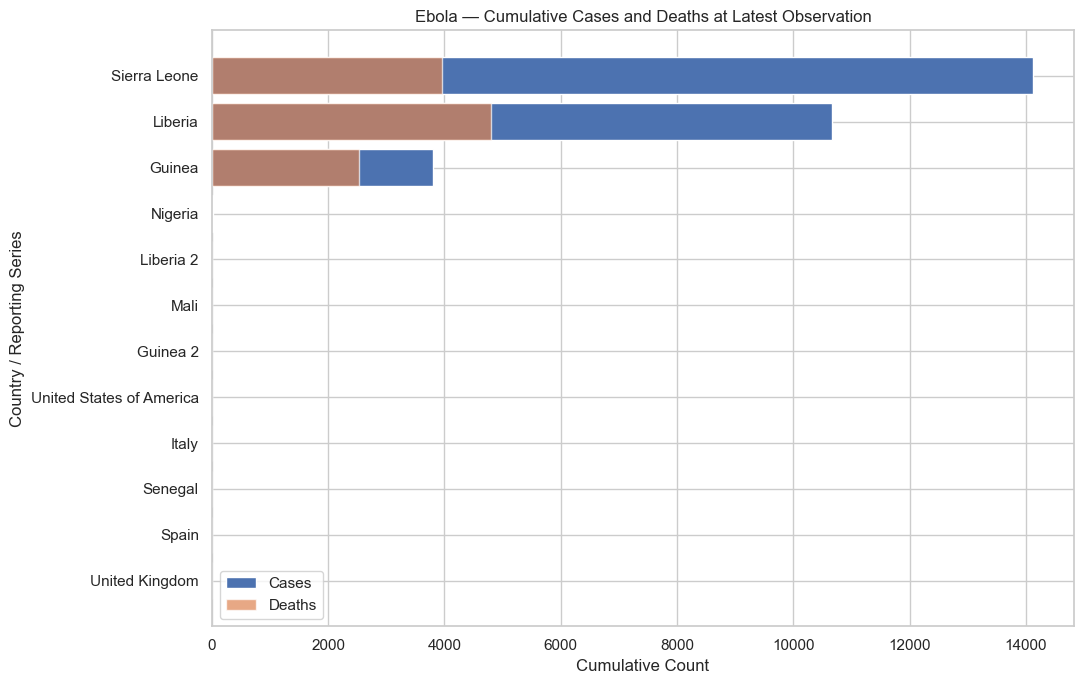

In [40]:
# ==========================================
#  FINAL CASES AND DEATHS BY COUNTRY
# ==========================================

import matplotlib.pyplot as plt

# Sort for a readable chart layout
plot_final = final_by_country.sort_values(
    "total_cases_all",
    ascending=True
)

plt.figure(figsize=(11, 7))

plt.barh(
    plot_final["Country"],
    plot_final["total_cases_all"],
    label="Cases"
)

plt.barh(
    plot_final["Country"],
    plot_final["total_deaths_all"],
    label="Deaths",
    alpha=0.7
)

plt.xlabel("Cumulative Count")
plt.ylabel("Country / Reporting Series")

plt.title(
    "Ebola — Cumulative Cases and Deaths at Latest Observation"
)

plt.legend()

plt.tight_layout()
plt.show()


# 18.2  Comparison of the Three Main Epidemic Series

Sierra Leone, Liberia, and Guinea concentrate the vast majority of cases reported in the dataset.
A separate visualization allows for a clearer comparison of the cumulative numbers of cases and deaths across these three countries.


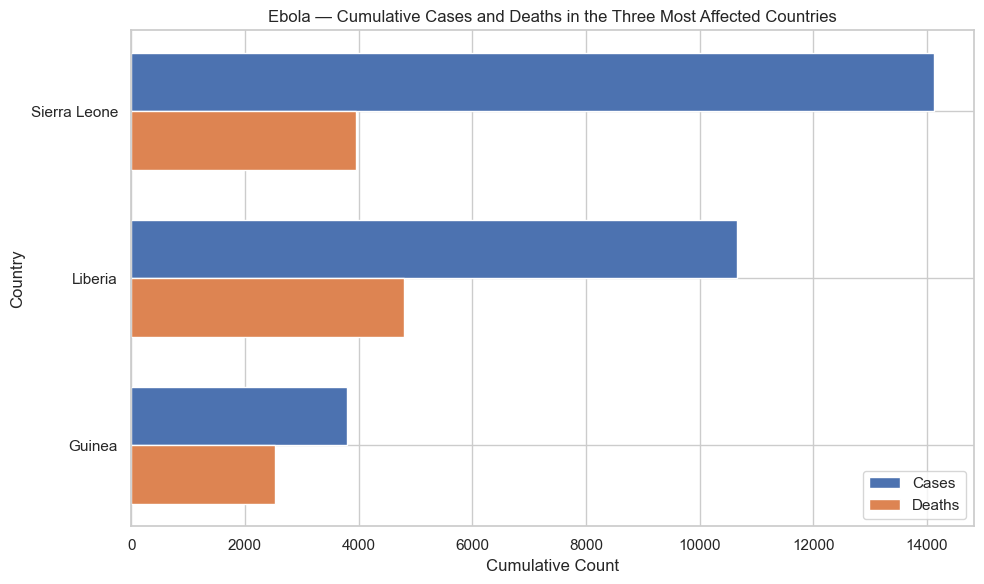

In [41]:
# ==========================================
# THREE MAIN COUNTRIES
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Select the three main series
main_countries = final_by_country[
    final_by_country["Country"].isin(
        ["Guinea", "Liberia", "Sierra Leone"]
    )
].copy()

# Sort based on the number of cases
main_countries = main_countries.sort_values(
    "total_cases_all",
    ascending=True
)

# Positions on the vertical axis
y_pos = np.arange(len(main_countries))
bar_height = 0.35

plt.figure(figsize=(10, 6))

# Bars for cases
plt.barh(
    y_pos + bar_height / 2,
    main_countries["total_cases_all"],
    height=bar_height,
    label="Cases"
)

# Bars for deaths
plt.barh(
    y_pos - bar_height / 2,
    main_countries["total_deaths_all"],
    height=bar_height,
    label="Deaths"
)

# Country names
plt.yticks(
    y_pos,
    main_countries["Country"]
)

plt.xlabel("Cumulative Count")
plt.ylabel("Country")

plt.title(
    "Ebola — Cumulative Cases and Deaths in the Three Most Affected Countries"
)

plt.legend()
plt.tight_layout()
plt.show()


# 18.3 Comparative Heatmap of Epidemiological Indicators

A heatmap is used to simultaneously compare the relative levels of cumulative cases, cumulative deaths,
and the Case Fatality Ratio (CFR) across the different reporting series.

The variables are normalized to prevent the absolute numbers of cases and deaths from visually dominating the CFR.


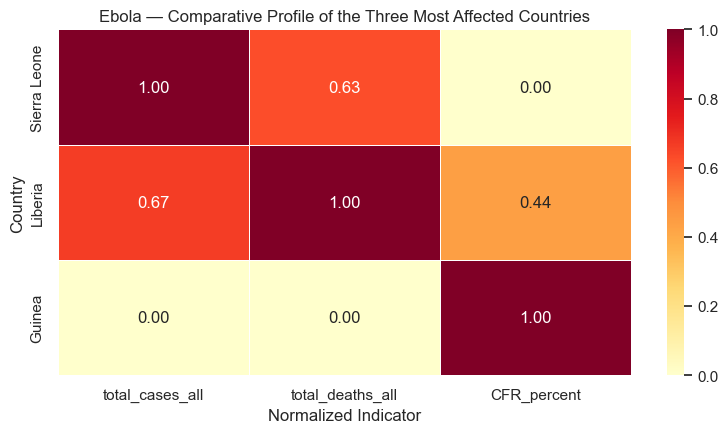

In [42]:

# ==========================================
# Q4 — HEATMAP OF THE THREE MAIN COUNTRIES
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select the three main countries
heatmap_main = final_by_country[
    final_by_country["Country"].isin(
        ["Guinea", "Liberia", "Sierra Leone"]
    )
].copy()

# Calculate CFR
heatmap_main["CFR_percent"] = (
    heatmap_main["total_deaths_all"]
    / heatmap_main["total_cases_all"]
    * 100
)

# Set Country as index
heatmap_values = heatmap_main.set_index("Country")[
    [
        "total_cases_all",
        "total_deaths_all",
        "CFR_percent"
    ]
]

# Min-Max Normalization
heatmap_norm = (
    heatmap_values - heatmap_values.min()
) / (
    heatmap_values.max() - heatmap_values.min()
)

# Plotting the Heatmap
plt.figure(figsize=(8, 4.5))
sns.heatmap(
    heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title(
    "Ebola — Comparative Profile of the Three Most Affected Countries"
)

plt.xlabel("Normalized Indicator")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


# 19. Key Findings & Summary

## 📊 Key Findings

### 1. Epidemic Magnitude
* **Core Concentration:** Sierra Leone, Liberia, and Guinea clearly dominate the dataset in terms of reported cumulative cases and deaths.
* **Volume Distribution:** Sierra Leone recorded the **highest cumulative number of cases**, while Liberia recorded the **highest cumulative number of deaths** among the three main reporting series.

### 2. Case Fatality Ratio (CFR)
* **Main Series Variance:** Among the three main countries, **Guinea had the highest final CFR (~66.7%)**, followed by Liberia (~45.1%) and Sierra Leone (~28.0%).
* **Sample Size Bias:** Some smaller reporting series show high CFR values, but these percentages should be interpreted cautiously because they are based on a very small absolute number of cases.

### 3. Data Quality and Reporting
* **Fragmented Streams:** The dataset contains multiple reporting series for certain countries (e.g., `Liberia 2` and `Guinea 2`).
* **Aggregation Risks:** This highlights the absolute importance of separating individual reporting series before attempting to aggregate or compare epidemiological indicators.
* **Context-Aware Imputation:** Eight missing case values were identified post-pivot. Contextual analysis of surrounding rows revealed stable cumulative plateaus, justifying the use of bounded linear interpolation.

### 4. Comparative Analysis
* **Distinct Profiles:** Final visualizations highlighted three contrasting epidemiological footprints:
  * **Sierra Leone** displays the highest cumulative case burden.
  * **Liberia** displays the highest cumulative death toll.
  * **Guinea** displays the highest CFR among the core regions.
* **Multi-Variable View:** The normalized heatmap effectively contextualized these differences by standardizing the scale across all three metrics simultaneously.

***

## 🏁 Conclusion

This project establishes a complete end-to-end **Exploratory Data Analysis (EDA) workflow**—spanning from data parsing and textual sanitization to structural reshaping, missing-value imputation, epidemiological calculation, and advanced visualization.

Rather than prematurely feeding raw, cumulative counts into complex Machine Learning models, this pipeline successfully extracted **meaningful descriptive and temporal patterns** grounded in the observed reporting data. 

The engineered, clean dataset (`df_clean`) now offers a highly reproducible and reliable foundation for downstream statistical analysis or dedicated time-series modeling.
